In [1]:
import joblib

X_train_scaled = joblib.load("X_train_scaled.pkl")
X_val_scaled = joblib.load("X_val_scaled.pkl")
X_test_scaled = joblib.load("X_test_scaled.pkl")

y_train = joblib.load("y_train.pkl")
y_val = joblib.load("y_val.pkl")
y_test = joblib.load("y_test.pkl")

In [3]:
q1 = y_train.quantile(0.33)
q2 = y_train.quantile(0.66)

def categorize(value):
    if value <= q1:
        return 0
    elif value <= q2:
        return 1
    else:
        return 2

y_train_class = y_train.apply(categorize)
y_val_class = y_val.apply(categorize)
y_test_class = y_test.apply(categorize)

In [5]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svm_linear = SVC(kernel='linear', C=1)

svm_linear.fit(X_train_scaled, y_train_class)

val_pred_linear = svm_linear.predict(X_val_scaled)

print("Validation Accuracy (Linear SVM):",
      accuracy_score(y_val_class, val_pred_linear))

Validation Accuracy (Linear SVM): 0.7154392764857881


In [6]:
svm_rbf = SVC(kernel='rbf', C=1, gamma='scale')

svm_rbf.fit(X_train_scaled, y_train_class)

val_pred_rbf = svm_rbf.predict(X_val_scaled)

print("Validation Accuracy (RBF SVM):",
      accuracy_score(y_val_class, val_pred_rbf))

Validation Accuracy (RBF SVM): 0.7406330749354005


In [7]:
for C_value in [0.1, 1, 10]:
    svm = SVC(kernel='rbf', C=C_value)
    svm.fit(X_train_scaled, y_train_class)
    val_pred = svm.predict(X_val_scaled)
    print("C =", C_value,
          "Validation Accuracy =",
          accuracy_score(y_val_class, val_pred))

C = 0.1 Validation Accuracy = 0.7031653746770026
C = 1 Validation Accuracy = 0.7406330749354005
C = 10 Validation Accuracy = 0.7619509043927648


In [9]:
best_svm = SVC(kernel='rbf', C=10)
best_svm.fit(X_train_scaled, y_train_class)

SVC(C=10)

In [10]:
from sklearn.metrics import classification_report, confusion_matrix

test_pred_svm = best_svm.predict(X_test_scaled)

print("Test Accuracy (SVM):",
      accuracy_score(y_test_class, test_pred_svm))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_class, test_pred_svm))

print("\nClassification Report:")
print(classification_report(y_test_class, test_pred_svm))

Test Accuracy (SVM): 0.7761627906976745

Confusion Matrix:
[[820 183  17]
 [143 710 156]
 [ 15 179 873]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.80      0.82      1020
           1       0.66      0.70      0.68      1009
           2       0.83      0.82      0.83      1067

    accuracy                           0.78      3096
   macro avg       0.78      0.78      0.78      3096
weighted avg       0.78      0.78      0.78      3096



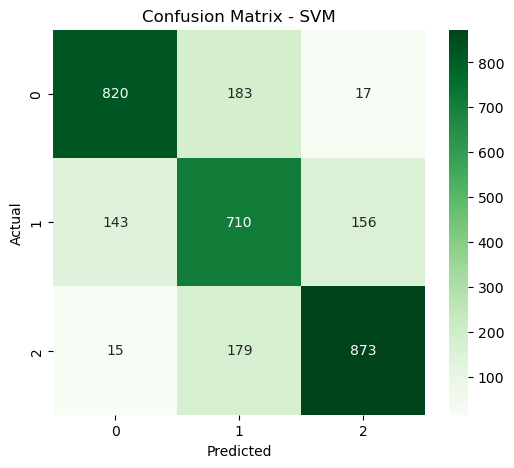

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_class, test_pred_svm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Greens")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM")
plt.show()

In [13]:
rf_model = joblib.load("classification_model.pkl")

rf_test_pred = rf_model.predict(joblib.load("X_test.pkl"))

print("Random Forest Test Accuracy:",
      accuracy_score(y_test_class, rf_test_pred))

Random Forest Test Accuracy: 0.8226744186046512
